### Homework

1. Train NN model with custom linear architecture on MNIST or on any dataset from Kaggle (image data with resolution not higher than 80x80 pixels - 
[Sign language MNIST](https://www.kaggle.com/datasets/datamunge/sign-language-mnist), 
[A-Z Handwritten Alphabet](https://www.kaggle.com/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format), etc.)
2. Visualize epoch progress (loss and accuracy curves)
3. Visualize 10 random elements from test set and model results for those elements

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

data = pd.read_csv('A_Z Handwritten Data.csv')

In [13]:
data

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372445,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372446,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372447,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372448,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values 

X = X / 255.0

y_categ = to_categorical(y, num_classes=26)

X_train, X_test, y_train, y_test = train_test_split(X, y_categ, test_size=0.2, random_state=42)

In [15]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(26, activation='softmax') 
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

E:\Anaconda\envs\tfcpu\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
history = model.fit(X_train, y_train, epochs=20, batch_size=128, validation_split=0.1)

Epoch 1/20
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.7915 - loss: 0.7395 - val_accuracy: 0.9529 - val_loss: 0.1648
Epoch 2/20
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9352 - loss: 0.2270 - val_accuracy: 0.9658 - val_loss: 0.1183
Epoch 3/20
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9477 - loss: 0.1782 - val_accuracy: 0.9679 - val_loss: 0.1067
Epoch 4/20
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9543 - loss: 0.1557 - val_accuracy: 0.9709 - val_loss: 0.0981
Epoch 5/20
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9579 - loss: 0.1415 - val_accuracy: 0.9753 - val_loss: 0.0867
Epoch 6/20
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9602 - loss: 0.1324 - val_accuracy: 0.9750 - val_loss: 0.0861
Epoch 7/20
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9629 - loss: 0.1248 - val_accuracy: 0.9764 - val_loss: 0.0781
Epoch 8/20
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9641 - loss: 0

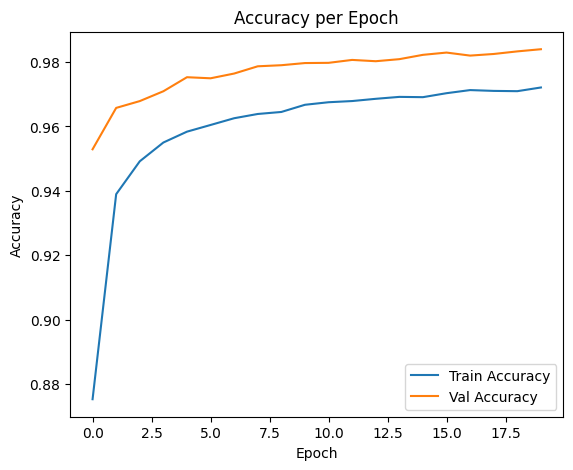

In [21]:
plt.figure(figsize=(14,5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

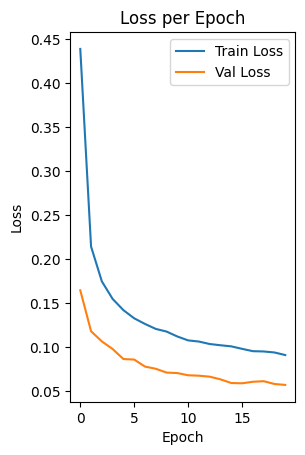

In [23]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

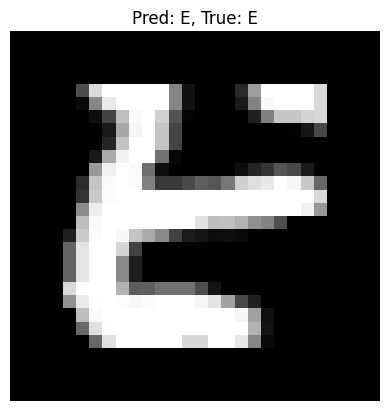

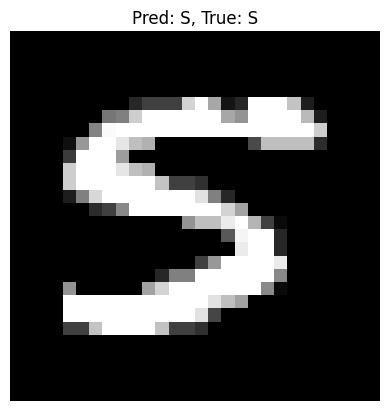

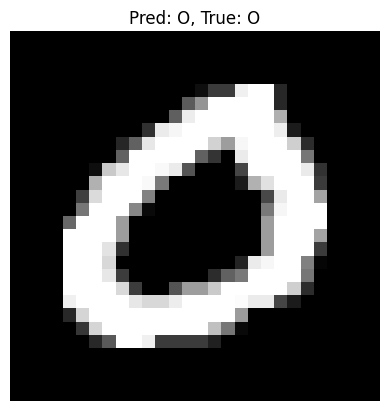

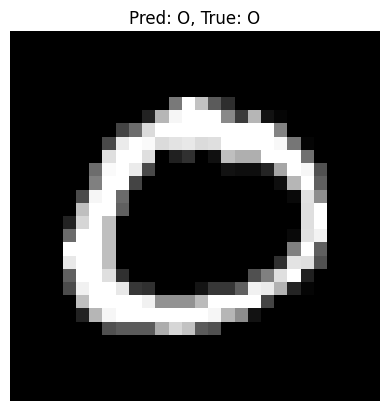

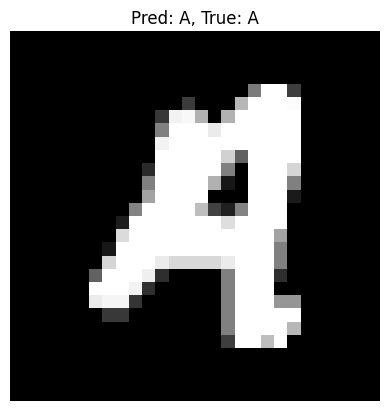

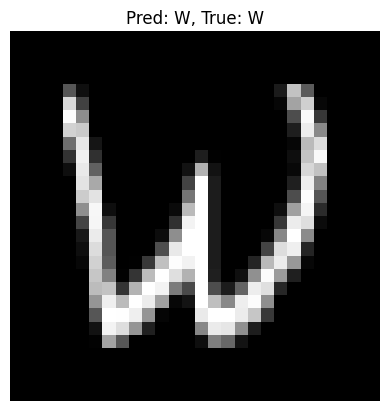

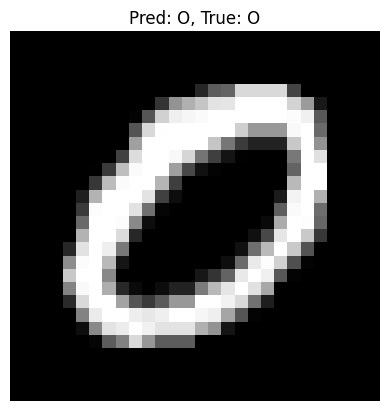

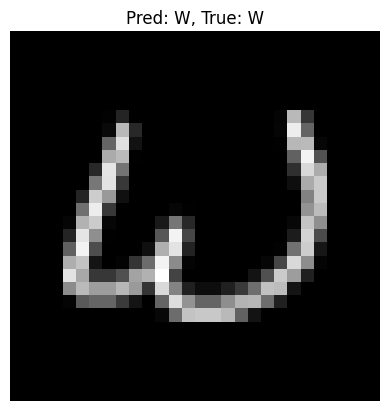

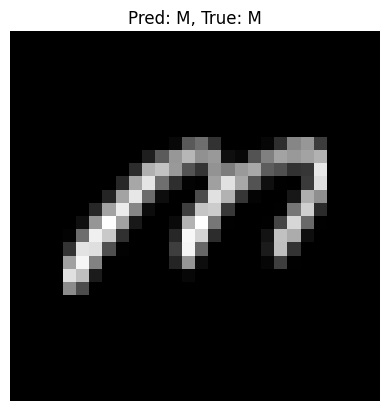

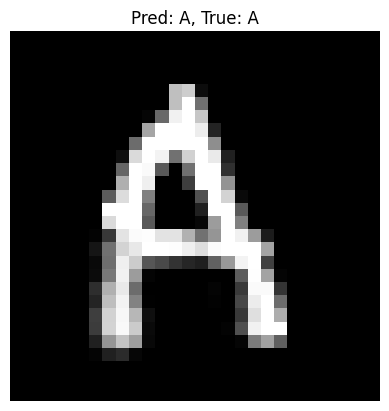

In [22]:
for i in np.random.choice(len(X_test), 10, replace=False):
    img = X_test[i].reshape(28, 28)
    prediction = model.predict(X_test[i][None], verbose=0)
    predicted_label = chr(np.argmax(prediction) + 65)
    true_label = chr(np.argmax(y_test[i]) + 65)

    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {predicted_label}, True: {true_label}")
    plt.axis('off')
    plt.show()